## Sección 1 - Cargar y explorar el dataset

Validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

In [27]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Cargar Dataset

In [28]:
# Cargar el dataset y explorar datos
df = pd.read_csv("/datasets/novaretail_comportamiento_clientes_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [29]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

In [30]:
# Corregir el tipo de dato
df['edad']=df['edad'].astype(int)

In [31]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [32]:
# Estadísticas descriptivas de variables numéricas
columnas_num='edad','nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida','satisfaccion','ingreso_anual'
for col in columnas_num:
   print(df[col].describe())

count    15000.000000
mean        38.262400
std         11.492378
min         18.000000
25%         30.000000
50%         38.000000
75%         46.000000
max         75.000000
Name: edad, dtype: float64
count    15000.000000
mean     30019.704782
std       9833.166305
min       8000.000000
25%      23127.097500
50%      30023.745000
75%      36768.440000
max      74790.840000
Name: nivel_ingreso, dtype: float64
count    15000.000000
mean        10.029000
std          3.158189
min          1.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         25.000000
Name: visitas_mes, dtype: float64
count    15000.000000
mean         1.206467
std          1.105284
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          8.000000
Name: compras_mes, dtype: float64
count    15000.000000
mean        20.149301
std         10.880724
min          0.000000
25%         12.310000
50%         19.730000
75%         27.292500
max        

Diagnóstico inicial de variables numéricas

- `edad`,datos con distribucion normal, no outliers. Suscriptores mayores de 18.
- `nivel ingreso`, datos con distribucion normal, promedio igual a mediana. Ingreso minimo de 8000.
- `visitas mes`, ningun cliente sin visitas por mes, datos con distribucion normal.
- `compras mes`, clientes sin compras con mes, distribucion con ligero sesgo a la derecha, sin valores extremos.
- `gasto publicidad dirigida`, clientes sin gasto de publicidad, sin valores extremos, por lo que se ve ligero sesgo hacia la derecha.
- `satisfaccion`, datos con distribucion normal, promedio mayor a 3,5 por lo que da a entender una satisfaccion generalmente aceptable.
- `ingreso anual`, columna con mayor sesgo del grupo, clientes sin gasto durante el an.

#### Explorar variables binarias

In [33]:
# Verificar que cada columna tenga únicamente dos valores posibles
df[['miembro_premium','abandono']].nunique()

miembro_premium    2
abandono           2
dtype: int64

Diagnóstico inicial de variables binarias

- `miembro_premium` — columna con datos acorde para el analisis binario.
- `abandono` — columna con datos acorde para el analsis binario.

#### Explorar variables categóricas

In [34]:
# Verificar el número de valores únicos por variable categórica
df[['tipo_dispositivo','region']].nunique()

tipo_dispositivo    3
region              4
dtype: int64

In [35]:
# Explorar variables categóricas y cómo se distribuyen
df[['tipo_dispositivo','region']].describe()

,tipo_dispositivo,region
count,15000,15000
unique,3,4
top,móvil,norte
freq,9818,4395


Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — el tipo de dispositivo mas frecuente es el movil con casi 2/3 del total.

- `region`- region con mas usuarios es la norte.

### Supuestos

Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones


### Heatmap

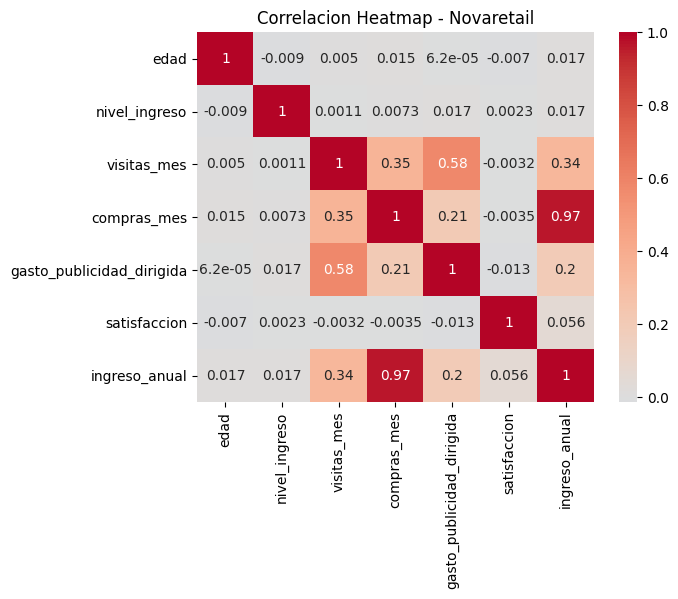

In [36]:
# Visualizar la matriz de correlación para identificar relaciones
df_num=df[['edad','nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida','satisfaccion','ingreso_anual']]
num_corr=df_num.corr()
sns.heatmap(num_corr,annot=True,cmap='coolwarm',center=0)
plt.title('Correlacion Heatmap - Novaretail')
plt.show()

Observaciones generales (Heatmap)  
- Se observa poca correlacion en la gran mayoria de parametros, con excepcion de visitas mes, compra mes y gasto de publicidad dirigida, las cuales tiene correlaciones positivas entre ellas. Pudiendo pensar que dependiendo del numero de visitas que haga l persona afectara que tantas compras hace y dependiendo de esto el presupuesto del gasto en publicidad que recibe esta persona. 

Observaciones respecto a `ingreso_anual`  
- Presenta una muy fuerte correlacion con el numero de compras por mes, lo que es muy precedible ya que ingreso anual puede estar posiblemente calculado pa partir de este numero.


### Scatterplot para pares clave

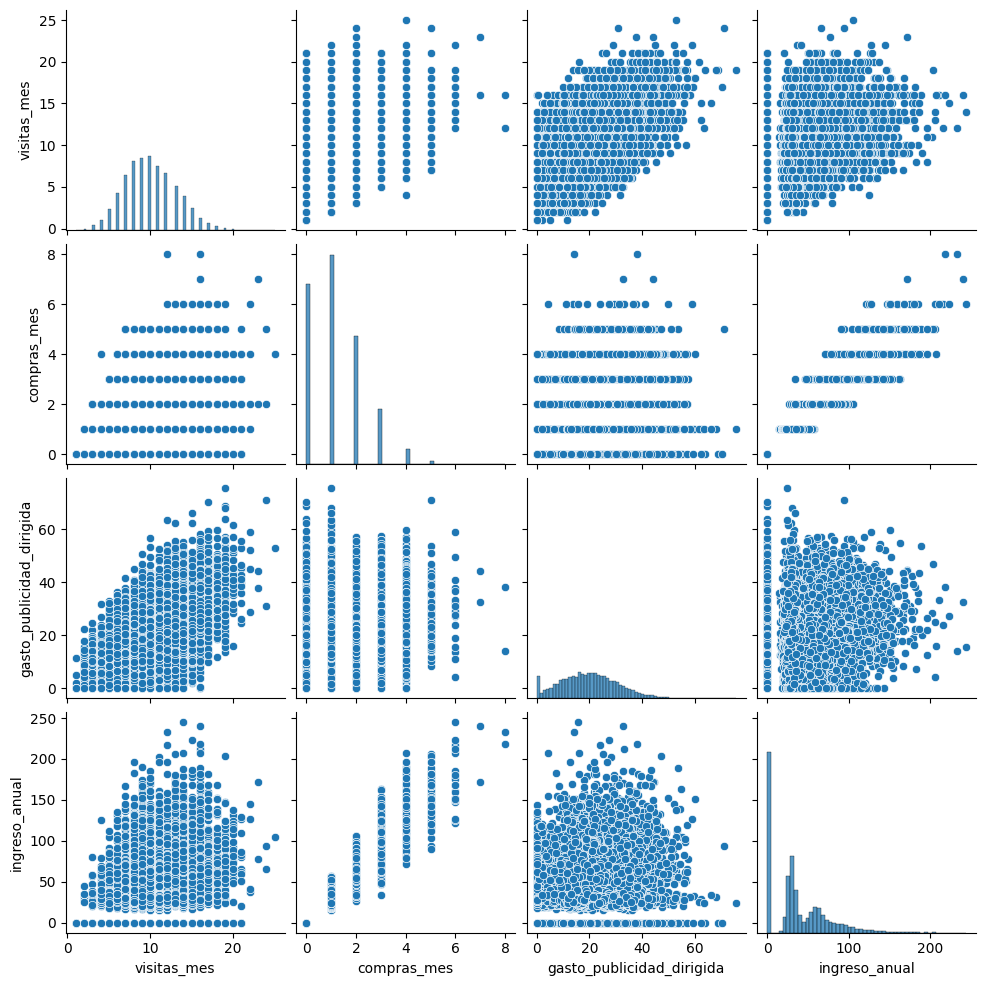

In [38]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.pairplot(df[['visitas_mes','compras_mes','gasto_publicidad_dirigida','ingreso_anual']])
plt.show()

Observaciones iniciales (Scatterplot)

**visitas_mes vs gasto_publicidad_dirigida**
- Dirección positiva, con una tendencia aparentemente lineal.

**visitas_mes vs compras_mes**
- Dirección positiva, con algunas dispersiones, pero que aun asi marcan una tendenia lineal.

**compras_mes vs ingreso_anual**
- Direccion positiva, fuerte correlacion lineal.

**visitas_mes vs ingreso_anual**
- Direccion positiva, con correlacion lineal.


## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [15]:
# Calcular correlación entre variables relevantes
print(df['visitas_mes'].corr(df['gasto_publicidad_dirigida'],method='pearson'))

print(df['visitas_mes'].corr(df['compras_mes'],method='pearson'))

print(df['compras_mes'].corr(df['ingreso_anual'],method='pearson'))

print(df['visitas_mes'].corr(df['ingreso_anual'],method='pearson'))

0.5789472719412827
0.3538438947198978
0.9671485435708564
0.3371466432498745


In [17]:
# Calcular correlación entre variables relevantes
print(df['visitas_mes'].corr(df['gasto_publicidad_dirigida'],method='spearman'))

print(df['visitas_mes'].corr(df['compras_mes'],method='spearman'))

print(df['compras_mes'].corr(df['ingreso_anual'],method='spearman'))

print(df['visitas_mes'].corr(df['ingreso_anual'],method='spearman'))

0.5592673242622609
0.33294292722789276
0.967482492032673
0.32095369737696483


Todas las correlaciones son lineales, todas presentan mayor afinidad es decir un valor de pearson mayor, o igual a spearman.

### Punto-biserial

In [18]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

point_premium=pointbiserialr(df['miembro_premium'],df['ingreso_anual'])
print(f'Relacion biserial ingreso anual - miembro premium: {point_premium}')
point_abandono=pointbiserialr(df['abandono'],df['ingreso_anual'])
print(f'Relacion biserial ingreso anual - abandono: {point_abandono}')


Relacion biserial ingreso anual - miembro premium: SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)
Relacion biserial ingreso anual - abandono: SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)


Observaciones Punto-biserial

**ingreso_anual vs miembro_premium**
- Relación tiene un valor casi nulo, aunque ligeramente positivo.

**ingreso_anual vs abandono**
- Relación con un valor casi nulo, aunque ligeramente positivo.

### V de Cramér

In [22]:
# Función para calcular V de Cramér
def cramer(df,col1,col2):
    tabla=pd.crosstab(df[col1],df[col2])
    chi2,p,dof,expected=chi2_contingency(tabla)
    n=tabla.sum().sum()
    v=np.sqrt(chi2/(n*(min(tabla.shape)-1)))
    return v

In [24]:
# Aplicar V de Cramér en variables relevantes
from scipy.stats import chi2_contingency
cramer(df,'region','tipo_dispositivo')


0.012378338407739397

Las correlacion entre las dos columnas categoricas de `region` y `tipo_dispositivo` es de tipo positivo con un valor muy cercano a cero, lo cual indica una correlacion muy debil, practimanente inexistente. 


## Sección 5 - Interpretación de resultados para el negocio

### Hallazgo 1 — 

**Evidencia visual:**  
Realizacion de un heatmap general, que al verse su relevancia se realizo un scatterplot. 
**Evidencia numérica:** 
correlacion directa, lineal moderada por un valor xx al realizar la correlacion de pearson y speacman.
**Interpretación**  
Es posible que la correlacion positiva entre `visitas_mes` y `gasto_publicidad_dirigida` sea inversa, ya que debido a un gasto mayor de publidad dirigida hacia un usuario, este por consecuencia haga mas visitas a la pagina.

**No podemos afirmar**  
Por lo tanto no se puede afirmar cual cause cual, o cual aumente porque la otra aumente

**Implicación de negocio**  
Que puede que a mayor inversion en publicidad se generen mas visitas que lleven a mas compras y por lo tanto a un refuerzo del sesgo.

### Hallazgo 2 — 

**Evidencia visual:**  
Mediante un heatmap general se ve una relacion positiva y mediana entre visitas por mes y compras por mes.
**Evidencia numérica:** 
Se ratifica esta relacion con el calculo de la correlacion de separman y specman, ratificando una relacion lineal positiva.
**Interpretación**  
Se ve una relacion lineal, con una correlacion de datos media entre el numero de visitas de un usuario y el numero de compras que realiza en el mes.

**No podemos afirmar**  
Que esto no se puede aplicar como regla general para todos los usuarios, ya que no se ha segmentado esto para ver el comportamiento por region, por tipo de usuario o tipo de movil.

**Implicación de negocio**  
Se podria intuir que a mayor visitas realice un usuario a la plataforma, mayor sera el numero de compras al mes


### Hallazgo 3 — 

**Evidencia visual:**  
N/A.

**Evidencia numérica:** 
Se realizo el calculo del valor de cramer obteniendo un valor casi nulo pero positivo entre las columnas categoricas de `region` y `tipo de dispositivo`.
**Interpretación**  
Que aparentmente no existe una correlacion entre estas dos columnas.

**No podemos afirmar**  
Que sea una regla general para todas las regiones, ya que aca tenemos un promedio global, ya que porbablemente al segmentarlo por region puede haber una correlacion leve con el tipo de dispositivo.

**Implicación de negocio**  
Que se puede segmentar para ver la correlacion por region y asi ver si se puede reforzar la publicidad a traves de cierto dispositivo en cada region.


## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Las correlaciones identificada de manera visual y confirmados de manera numerica no indican una causalidad entre datos, por lo que no se puede asegurar que al aumentar ciertos parametros se va a influir de manera directa aumentando valores importantes como el ingreso anual.
- Las correlaciones entre variables numericas no se realizo de manera segmentada, se hizo de manera global, por lo que se podria estar ocultando los resultados reales al no analizarlos en subgrupos.
- Al no tener informacion de usuarios y gastos en publicidad dirigida no se puede asegurar si uno es consecuancia del otro, por lo que se podria reforzar un sesgo. 

### **Próximos pasos** 

Probar segmentación adicional
- Se debe hacer de nuevo la correlacion de parametros importantes, pero segmentando este analisis por region.
- Se debe hacer el analsis de las correlaciones de estas variables numericas importates dependiendo del tipo de dispositivo.
